In [1]:
import pandas as pd
print("Notebook Working")


Notebook Working


In [2]:
import pandas as pd

nav = pd.read_csv("data/raw/02_nav_history.csv")

print(nav.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/02_nav_history.csv'

In [3]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())


   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [4]:
print(nav.columns)


Index(['amfi_code', 'date', 'nav'], dtype='str')


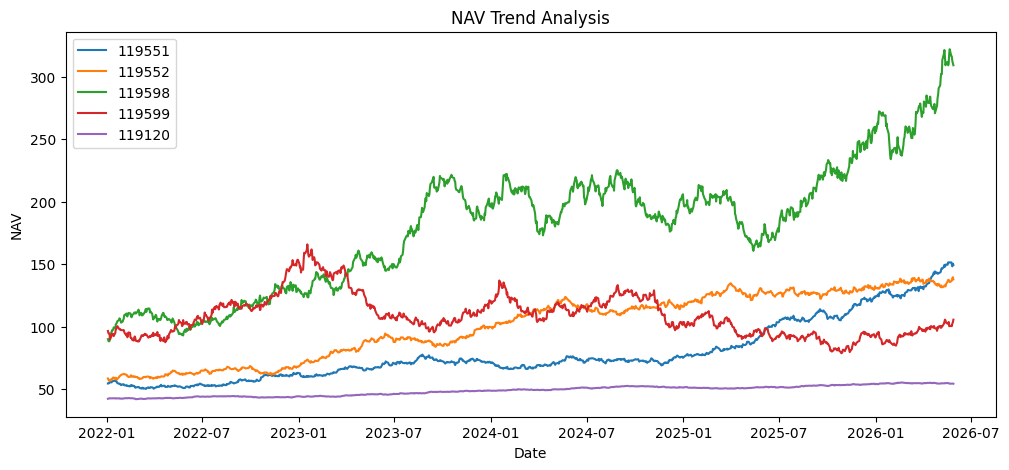

In [5]:
import matplotlib.pyplot as plt

nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,5))

for code in nav["amfi_code"].unique()[:5]:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=code)

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

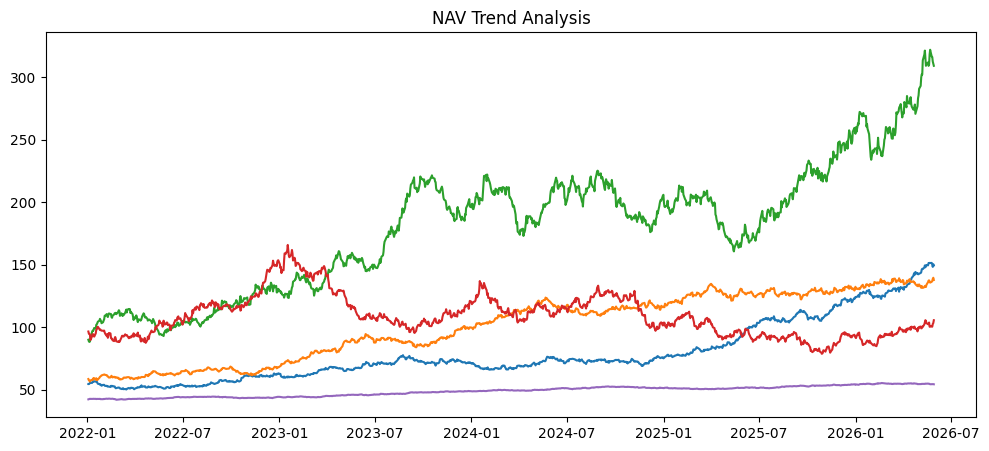

In [6]:
plt.figure(figsize=(12,5))

for code in nav["amfi_code"].unique()[:5]:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend Analysis")

plt.savefig(
    "../reports/nav_trend.png",
    bbox_inches="tight"
)

plt.show()

In [7]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [8]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


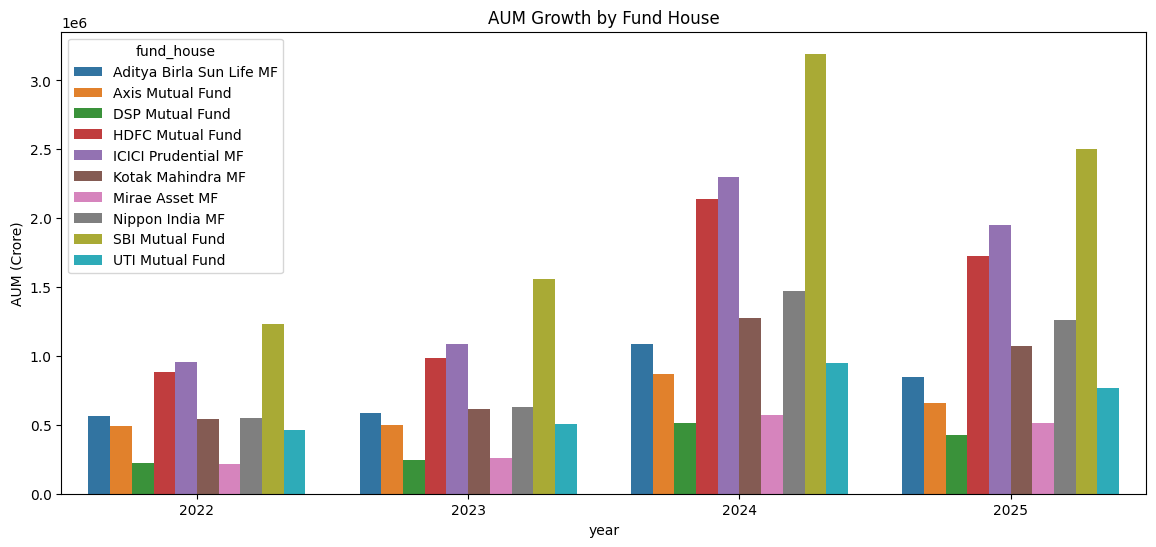

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

yearly_aum = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=0)

plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


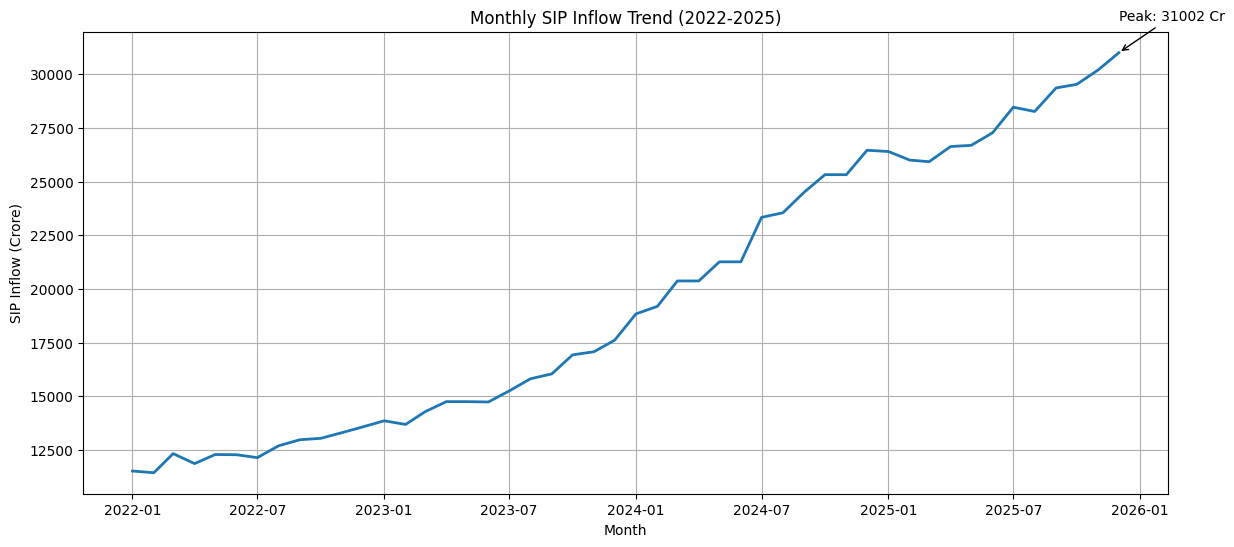

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

# Highest SIP inflow point
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"Peak: {max_row['sip_inflow_crore']} Cr",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] + 1500),
    arrowprops=dict(arrowstyle="->")
)

plt.savefig(
    "../reports/sip_trend.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())
print(category.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


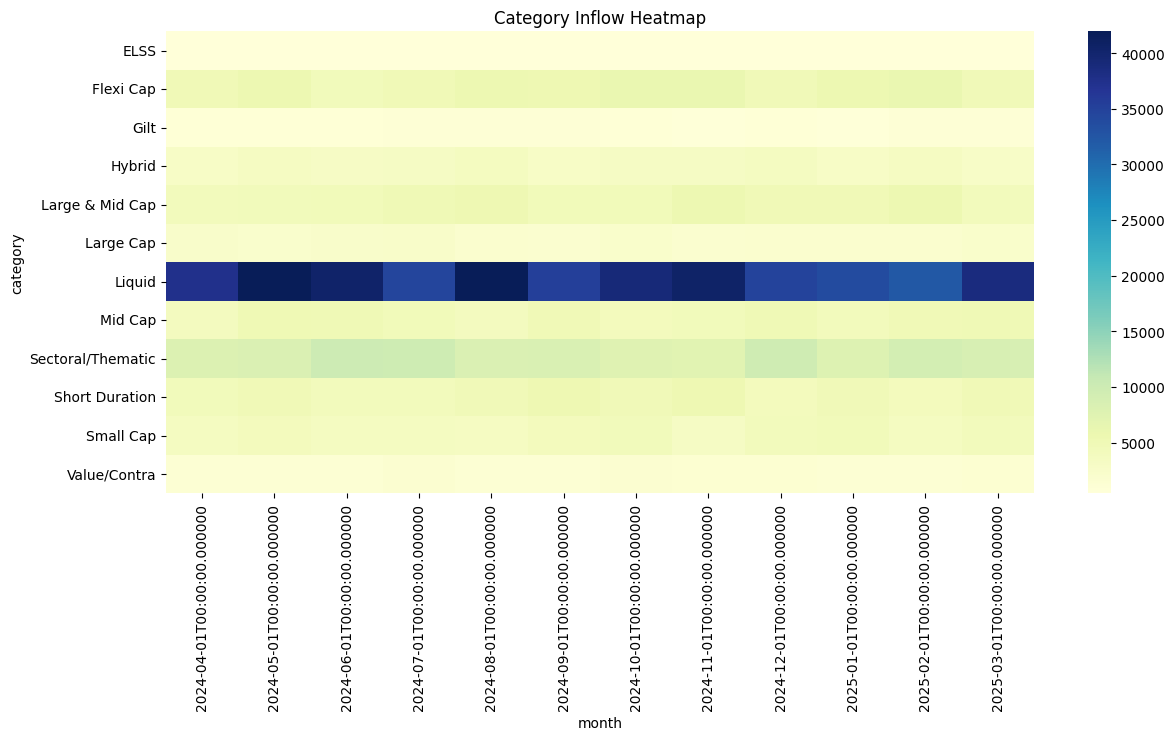

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

category = pd.read_csv("../data/raw/05_category_inflows.csv")

category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(investor.head())
print(investor.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

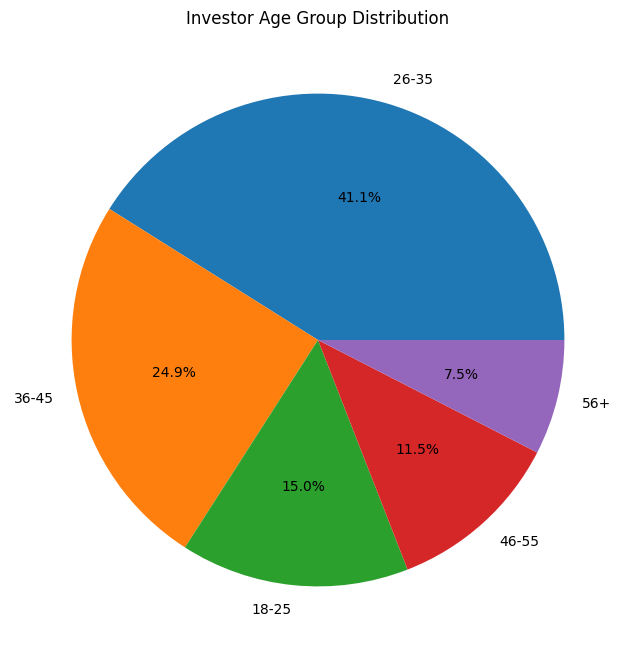

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

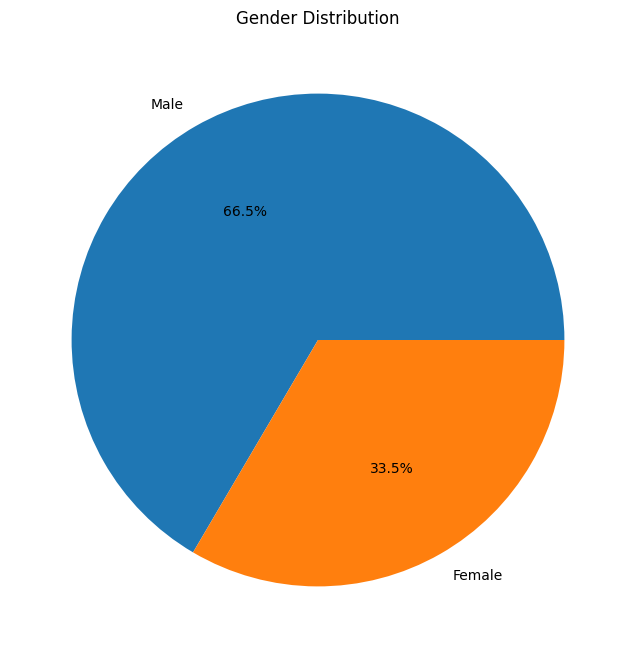

In [16]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

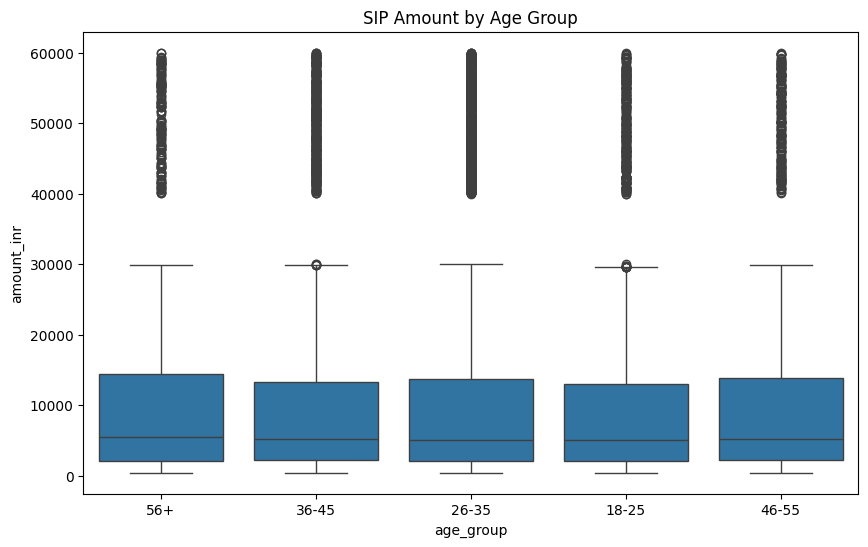

In [17]:
import seaborn as sns

investor["amount_inr"] = pd.to_numeric(
    investor["amount_inr"],
    errors="coerce"
)

sip_data = investor[
    investor["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig(
    "../reports/sip_age_group_boxplot.png",
    bbox_inches="tight"
)

plt.show()

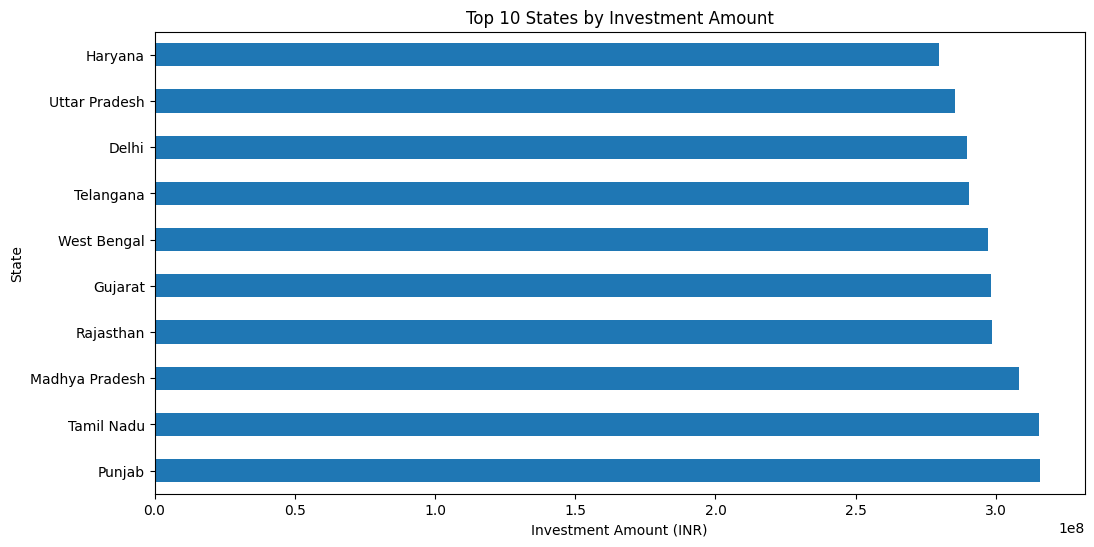

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor["amount_inr"] = pd.to_numeric(
    investor["amount_inr"],
    errors="coerce"
)

state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_data.plot(kind="barh")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.savefig(
    "../reports/state_investment.png",
    bbox_inches="tight"
)

plt.show()

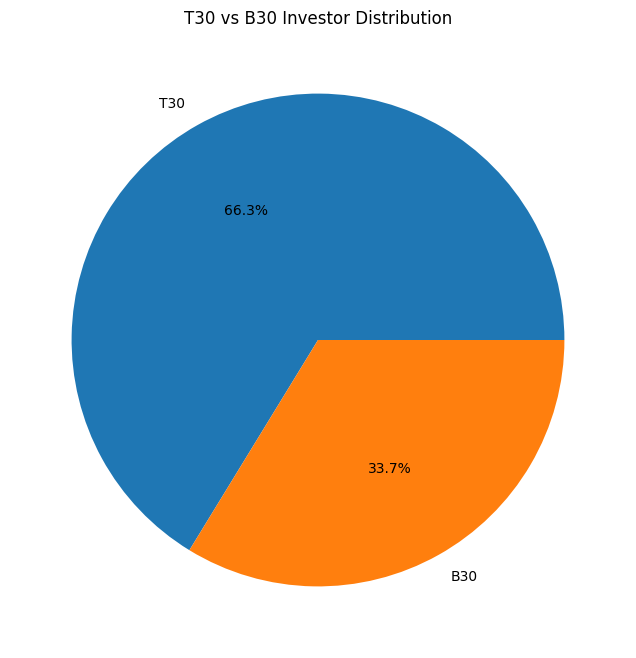

In [19]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
print(portfolio.columns)

NameError: name 'portfolio' is not defined

In [21]:
import pandas as pd

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.head())
print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


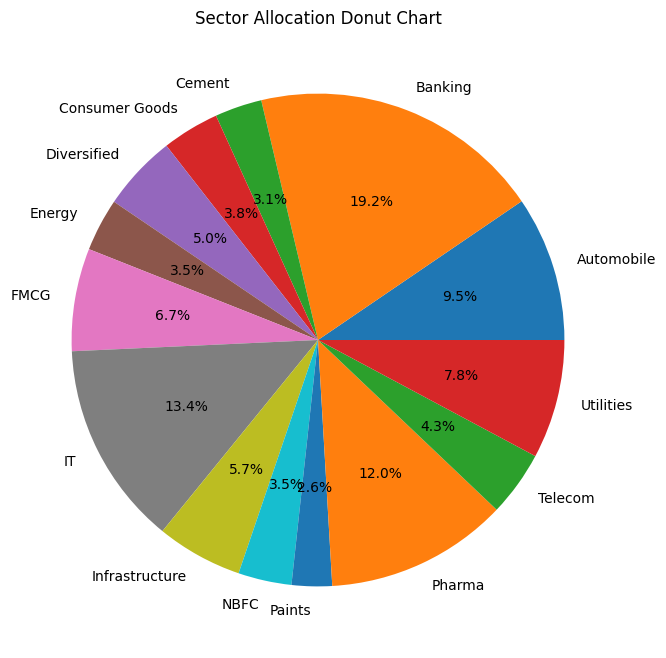

In [22]:
import matplotlib.pyplot as plt

sector_data = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Donut Chart")

plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

# Key EDA Findings

1. NAV values show an overall upward trend from 2022–2026.
2. SBI Mutual Fund has the highest AUM among major fund houses.
3. SIP inflows increased steadily over the analysis period.
4. Large Cap and Flexi Cap categories attracted strong inflows.
5. Investors from T30 cities contribute the majority of investments.
6. Age group 26–45 contributes most SIP transactions.
7. Portfolio holdings are concentrated in a few major sectors.
8. Banking and Financial Services have significant portfolio allocation.
9. Fund performance varies considerably across schemes.
10. Market corrections are visible during selected periods.